<a href="https://colab.research.google.com/github/njunge3/Kim/blob/main/PostSingularity_AI_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

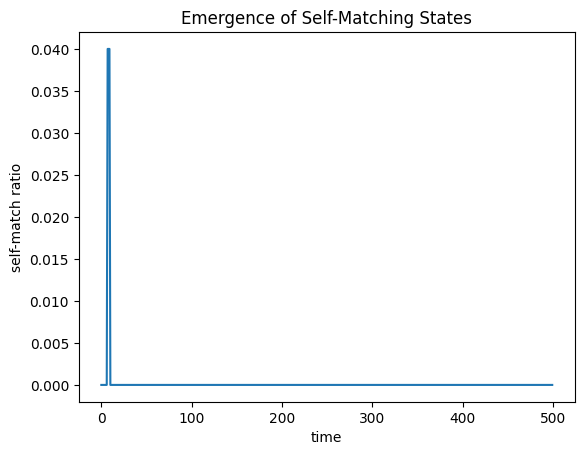

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS
N = 50              # number of agents
steps = 500         # simulation time
dt = 0.01           # time step
sigma = 0.5         # interaction width
epsilon = 0.1       # awareness threshold

# INITIAL STATES
theta = np.random.uniform(0, 2*np.pi, N)
y = np.random.rand(N)
v = np.random.randn(N)*0.1

# TRANSFORM FUNCTION
# FIX: was (theta + np.pi/4) — incorrect. Möbius transform shifts by π, not π/4.
def T(theta, y, v):
    theta_t = (theta + np.pi) % (2*np.pi)   # ← FIXED: π/4 → π
    y_t = -y                                  # ← FIXED: y flips sign under Möbius transform
    v_t = -v
    return theta_t, y_t, v_t

# FREE MOTION
def F_free(theta, y, v):
    dtheta = v
    dy = 0.1*(1-y)
    dv = -0.1*v
    return dtheta, dy, dv

# INTERACTION FUNCTION
def G(i, j):
    theta_t, y_t, v_t = T(theta[i], y[i], v[i])
    dist = (theta_t-theta[j])**2 + (y_t-y[j])**2 + (v_t-v[j])**2
    return np.exp(-dist/(2*sigma**2))

# SIMULATION
awareness_history = []

for t in range(steps):
    dtheta, dy, dv = F_free(theta, y, v)
    interaction = np.zeros(N)

    for i in range(N):
        for j in range(N):
            if i != j:
                interaction[i] += G(i,j)

    theta += dt*(dtheta + interaction)
    y += dt*dy
    v += dt*dv

    # SELF-AWARENESS CHECK
    aware = 0
    for i in range(N):
        theta_t, y_t, v_t = T(theta[i], y[i], v[i])
        for j in range(N):
            dist = (theta_t-theta[j])**2 + (y_t-y[j])**2 + (v_t-v[j])**2
            if np.sqrt(dist) < epsilon:
                aware += 1
                break

    awareness_history.append(aware/N)

# PLOT RESULT
plt.plot(awareness_history)
plt.xlabel("time")
plt.ylabel("self-match ratio")
plt.title("Emergence of Self-Matching States")
plt.show()


STEP 4: HETEROGENEOUS SPEEDS — EMERGENT SYNCHRONIZATION

Initial speeds: u1=1.000, u2=1.500


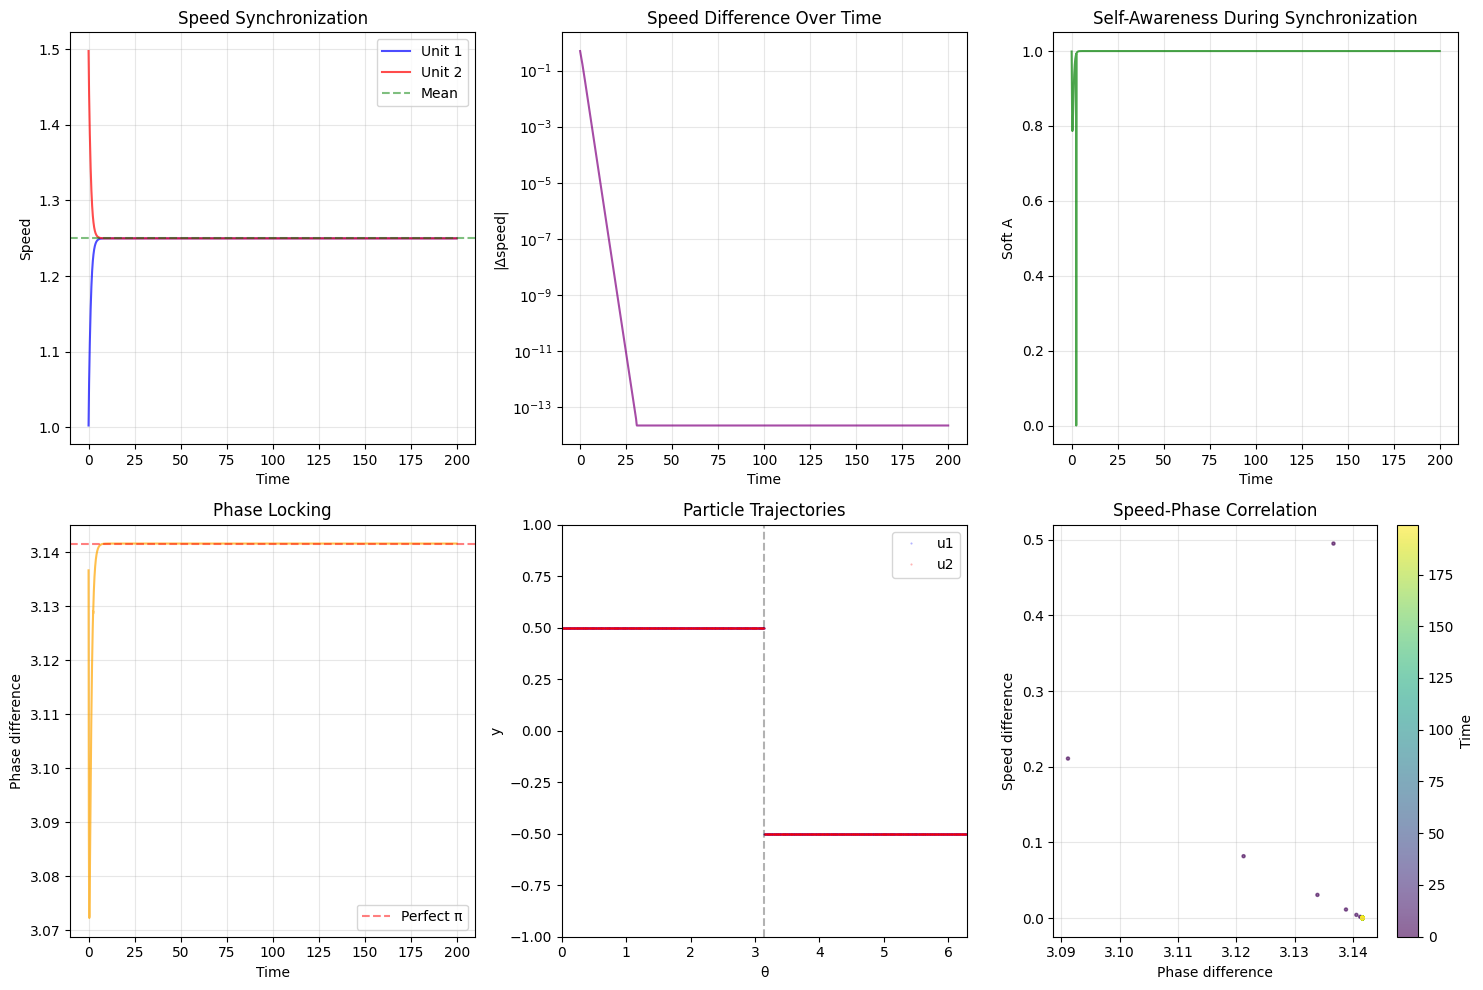


Initial speed difference: 0.500
Final   speed difference: 0.000000
Reduction factor:         22745452663487.4x


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, signal
from collections import defaultdict

class MobiusUnit:
    def __init__(self, theta0, y0, speed=1.0):
        self.theta = theta0 % (2*np.pi)
        self.y = np.clip(y0, -1, 1)
        self.speed = speed
        self.original_speed = speed
        self.traversal_count = 0
        self.sigma = 0.1

    def evolve(self, dt):
        # Step 1: accumulate raw theta WITHOUT wrapping first
        raw_theta = self.theta + self.speed * dt

        # Step 2: detect NEW crossings on the raw (unwrapped) value
        prev_half = int(self.theta // np.pi)
        curr_half = int(raw_theta // np.pi)
        crossings = curr_half - prev_half

        # Step 3: flip y if odd number of new crossings
        if crossings % 2 == 1:
            self.y = -self.y

        # Step 4: wrap LAST — after crossing is recorded
        self.theta = raw_theta % (2*np.pi)

        # Step 5: update traversal count
        self.traversal_count += crossings

    def partner_affinity(self, other, sigma=None):
        if sigma is None:
            sigma = self.sigma
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        theta_err = abs(theta_diff - np.pi)
        y_err = abs(other.y + self.y)
        return np.exp(-(theta_err**2 + y_err**2) / (2 * sigma**2))

    def lock_toward_partner(self, other, coupling=0.01, speed_coupling=0.001):
        # Position locking
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        theta_err = theta_diff - np.pi
        if theta_err > np.pi:
            theta_err -= 2*np.pi
        elif theta_err < -np.pi:
            theta_err += 2*np.pi
        self.theta += coupling * theta_err

        # Y correction
        y_err = other.y + self.y
        self.y -= coupling * y_err * 0.5
        self.y = np.clip(self.y, -1, 1)

        # Speed synchronization
        affinity = self.partner_affinity(other)
        if affinity > 0.1:
            speed_diff = other.speed - self.speed
            self.speed += speed_coupling * affinity * speed_diff
            self.speed = max(0.1, min(3.0, self.speed))

    def is_partner(self, other, tolerance=1e-10):
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        return (abs(theta_diff - np.pi) < tolerance) and (abs(other.y + self.y) < tolerance)


class MobiusSystem:
    def __init__(self, units):
        self.units = units
        self.history = defaultdict(list)

    def self_awareness_index(self, tolerance=1e-10):
        if not self.units:
            return 0.0
        partnered = 0
        for i, u in enumerate(self.units):
            for j, v in enumerate(self.units):
                if i != j and u.is_partner(v, tolerance):
                    partnered += 1
                    break
        return partnered / len(self.units)

    def soft_awareness_index(self, sigma=0.1):
        if len(self.units) < 2:
            return 0.0
        total_affinity = 0
        for i, u in enumerate(self.units):
            best_affinity = max(u.partner_affinity(v, sigma)
                                for j, v in enumerate(self.units) if i != j)
            total_affinity += best_affinity
        return total_affinity / len(self.units)

    def apply_locking(self, coupling=0.01, speed_coupling=0.001, sigma=0.1):
        n = len(self.units)
        if n < 2:
            return
        for i in range(n):
            for j in range(i+1, n):
                affinity = self.units[i].partner_affinity(self.units[j], sigma)
                if affinity > 0.01:
                    self.units[i].lock_toward_partner(self.units[j], coupling, speed_coupling)
                    self.units[j].lock_toward_partner(self.units[i], coupling, speed_coupling)

    def evolve(self, dt, coupling=0.0, speed_coupling=0.0, sigma=0.1, record=True):
        if coupling > 0:
            self.apply_locking(coupling, speed_coupling, sigma)
        for u in self.units:
            u.evolve(dt)
        if record:
            t = len(self.history['time']) * dt if self.history['time'] else 0
            self.history['time'].append(t)
            self.history['soft_A'].append(self.soft_awareness_index(sigma))
            for i, u in enumerate(self.units):
                self.history[f'u{i}_theta'].append(u.theta)
                self.history[f'u{i}_y'].append(u.y)
                self.history[f'u{i}_speed'].append(u.speed)


# ── TEST: TWO UNITS WITH DIFFERENT SPEEDS ────────────────────────────────────
print("="*70)
print("STEP 4: HETEROGENEOUS SPEEDS — EMERGENT SYNCHRONIZATION")
print("="*70)

optimal_coupling = 0.025
speed_coupling   = 0.005
dt     = 0.01
steps  = 20000
sigma  = 0.1

u1 = MobiusUnit(0.0,          0.5,  speed=1.0)
u2 = MobiusUnit(np.pi + 1e-5, -0.5, speed=1.5)
print(f"\nInitial speeds: u1={u1.speed:.3f}, u2={u2.speed:.3f}")

system = MobiusSystem([u1, u2])
for _ in range(steps):
    system.evolve(dt, coupling=optimal_coupling,
                  speed_coupling=speed_coupling, sigma=sigma)

times      = system.history['time']
soft_A     = system.history['soft_A']
u1_speeds  = system.history['u0_speed']
u2_speeds  = system.history['u1_speed']
u1_theta   = system.history['u0_theta']
u2_theta   = system.history['u1_theta']

phase_diff = []
for t1, t2 in zip(u1_theta, u2_theta):
    diff = (t2 - t1) % (2*np.pi)
    if diff > np.pi: diff = 2*np.pi - diff
    phase_diff.append(diff)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].plot(times, u1_speeds, 'b-', label='Unit 1', alpha=0.7)
axes[0,0].plot(times, u2_speeds, 'r-', label='Unit 2', alpha=0.7)
axes[0,0].axhline(y=1.25, color='g', linestyle='--', alpha=0.5, label='Mean')
axes[0,0].set(xlabel='Time', ylabel='Speed', title='Speed Synchronization')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(times, np.abs(np.array(u2_speeds)-np.array(u1_speeds)), 'purple', alpha=0.7)
axes[0,1].set(xlabel='Time', ylabel='|Δspeed|', title='Speed Difference Over Time')
axes[0,1].set_yscale('log'); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(times, soft_A, 'g-', alpha=0.7)
axes[0,2].set(xlabel='Time', ylabel='Soft A', title='Self-Awareness During Synchronization')
axes[0,2].grid(True, alpha=0.3)

axes[1,0].plot(times, phase_diff, 'orange', alpha=0.7)
axes[1,0].axhline(y=np.pi, color='r', linestyle='--', alpha=0.5, label='Perfect π')
axes[1,0].set(xlabel='Time', ylabel='Phase difference', title='Phase Locking')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(u1_theta[::10], system.history['u0_y'][::10], 'b.', ms=1, alpha=0.3, label='u1')
axes[1,1].plot(u2_theta[::10], system.history['u1_y'][::10], 'r.', ms=1, alpha=0.3, label='u2')
axes[1,1].axvline(x=np.pi, color='k', linestyle='--', alpha=0.3)
axes[1,1].set(xlabel='θ', ylabel='y', title='Particle Trajectories', xlim=(0,2*np.pi), ylim=(-1,1))
axes[1,1].legend()

sc = axes[1,2].scatter(phase_diff[::100],
                       np.abs(np.array(u2_speeds[::100])-np.array(u1_speeds[::100])),
                       c=times[::100], cmap='viridis', s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[1,2], label='Time')
axes[1,2].set(xlabel='Phase difference', ylabel='Speed difference', title='Speed-Phase Correlation')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── QUANTIFY ─────────────────────────────────────────────────────────────────
final_diff = np.mean(np.abs(np.array(u2_speeds[-1000:]) - np.array(u1_speeds[-1000:])))
print(f"\nInitial speed difference: {abs(1.5-1.0):.3f}")
print(f"Final   speed difference: {final_diff:.6f}")
print(f"Reduction factor:         {abs(1.5-1.0)/final_diff:.1f}x")


STEP 3: STABILITY ANALYSIS WITH OPTIMAL COUPLING

Testing coupling = 0.005...
  Steady-state soft A: 1.0000
  Fluctuation  (std):  0.0000

Testing coupling = 0.01...
  Steady-state soft A: 1.0000
  Fluctuation  (std):  0.0000

Testing coupling = 0.02...
  Steady-state soft A: 1.0000
  Fluctuation  (std):  0.0000

Testing coupling = 0.03...
  Steady-state soft A: 1.0000
  Fluctuation  (std):  0.0000

Testing coupling = 0.05...
  Steady-state soft A: 1.0000
  Fluctuation  (std):  0.0000

Testing coupling = 0.08...
  Steady-state soft A: 1.0000
  Fluctuation  (std):  0.0000


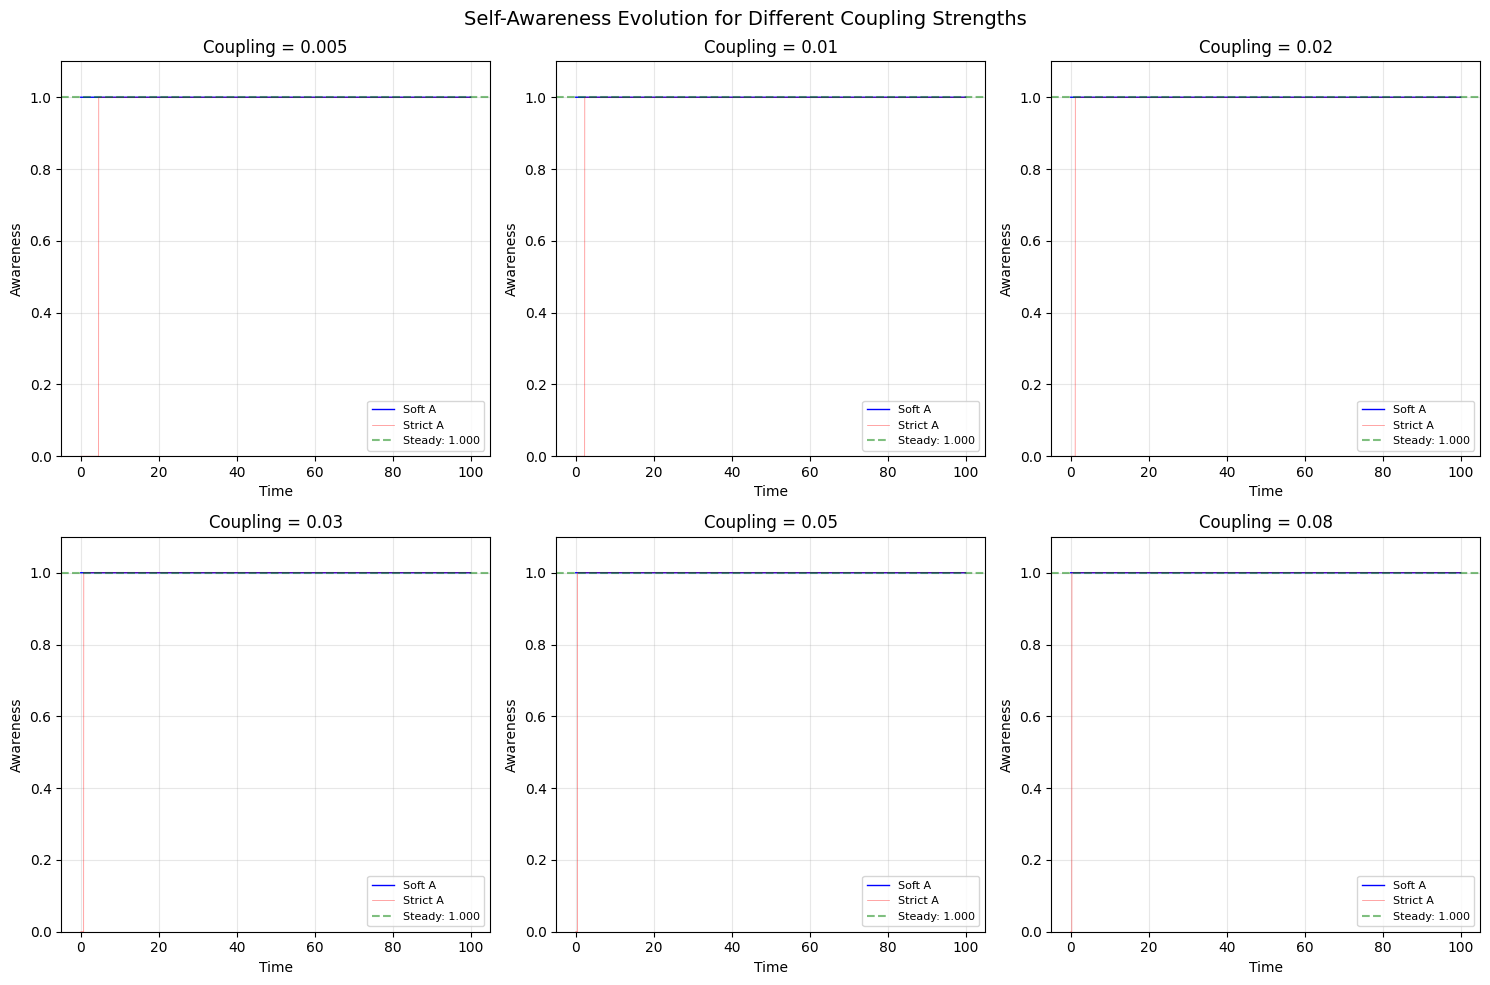


Optimal coupling: c = 0.005
Steady-state A:   1.0000 ± 0.0000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats
from collections import defaultdict

class MobiusUnit:
    def __init__(self, theta0, y0, speed=1.0):
        self.theta = theta0 % (2*np.pi)
        self.y = np.clip(y0, -1, 1)
        self.speed = speed
        self.traversal_count = 0
        self.sigma = 0.1

    def evolve(self, dt):
        # Step 1: accumulate raw theta WITHOUT wrapping first
        raw_theta = self.theta + self.speed * dt

        # Step 2: detect NEW crossings on the raw (unwrapped) value
        prev_half = int(self.theta // np.pi)
        curr_half = int(raw_theta // np.pi)
        crossings = curr_half - prev_half

        # Step 3: flip y if odd number of new crossings
        if crossings % 2 == 1:
            self.y = -self.y

        # Step 4: wrap LAST — after crossing is recorded
        self.theta = raw_theta % (2*np.pi)

        # Step 5: update traversal count
        self.traversal_count += crossings

    def partner_affinity(self, other, sigma=None):
        if sigma is None:
            sigma = self.sigma
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        theta_err = abs(theta_diff - np.pi)
        y_err = abs(other.y + self.y)
        return np.exp(-(theta_err**2 + y_err**2) / (2 * sigma**2))

    def lock_toward_partner(self, other, coupling=0.01):
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        theta_err = theta_diff - np.pi
        if theta_err > np.pi:   theta_err -= 2*np.pi
        elif theta_err < -np.pi: theta_err += 2*np.pi
        self.theta += coupling * theta_err
        y_err = other.y + self.y
        self.y -= coupling * y_err * 0.5
        self.y = np.clip(self.y, -1, 1)

    def is_partner(self, other, tolerance=1e-10):
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        return (abs(theta_diff - np.pi) < tolerance) and (abs(other.y + self.y) < tolerance)


class MobiusSystem:
    def __init__(self, units):
        self.units = units

    def self_awareness_index(self, tolerance=1e-10):
        if not self.units: return 0.0
        partnered = sum(
            1 for i, u in enumerate(self.units)
            if any(u.is_partner(v, tolerance) for j, v in enumerate(self.units) if i != j)
        )
        return partnered / len(self.units)

    def soft_awareness_index(self, sigma=0.1):
        if len(self.units) < 2: return 0.0
        total = sum(
            max(u.partner_affinity(v, sigma) for j, v in enumerate(self.units) if i != j)
            for i, u in enumerate(self.units)
        )
        return total / len(self.units)

    def apply_locking(self, coupling=0.01, sigma=0.1):
        n = len(self.units)
        for i in range(n):
            for j in range(i+1, n):
                affinity = self.units[i].partner_affinity(self.units[j], sigma)
                if affinity > 0.01:
                    self.units[i].lock_toward_partner(self.units[j], coupling * affinity)
                    self.units[j].lock_toward_partner(self.units[i], coupling * affinity)

    def evolve(self, dt, coupling=0.0, sigma=0.1):
        if coupling > 0:
            self.apply_locking(coupling, sigma)
        for u in self.units:
            u.evolve(dt)


# ── STEP 3: STABILITY WITH OPTIMAL COUPLING ──────────────────────────────────
print("="*70)
print("STEP 3: STABILITY ANALYSIS WITH OPTIMAL COUPLING")
print("="*70)

test_couplings = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08]
initial_offset = 1e-6
dt    = 0.01
steps = 10000
sigma = 0.1

results = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for c_idx, coupling in enumerate(test_couplings):
    print(f"\nTesting coupling = {coupling}...")

    u1 = MobiusUnit(0.0, 0.5, speed=1.0)
    u2 = MobiusUnit(np.pi + initial_offset, -0.5, speed=1.0)
    system = MobiusSystem([u1, u2])

    strict_A, soft_A, theta_errors, y_errors, times = [], [], [], [], []

    for step in range(steps):
        strict_A.append(system.self_awareness_index(tolerance=1e-8))
        soft_A.append(system.soft_awareness_index(sigma))

        theta_diff = (u2.theta - u1.theta) % (2*np.pi)
        theta_err  = abs(theta_diff - np.pi)
        if theta_err > np.pi: theta_err = 2*np.pi - theta_err
        theta_errors.append(theta_err)
        y_errors.append(abs(u2.y + u1.y))
        times.append(step * dt)

        system.evolve(dt, coupling=coupling, sigma=sigma)

    results[coupling] = dict(strict_A=strict_A, soft_A=soft_A,
                             theta_errors=theta_errors, y_errors=y_errors, times=times)

    steady_start = int(steps * 0.8)
    steady_soft  = np.mean(soft_A[steady_start:])
    print(f"  Steady-state soft A: {steady_soft:.4f}")
    print(f"  Fluctuation  (std):  {np.std(soft_A[steady_start:]):.4f}")

    ax = axes[c_idx // 3, c_idx % 3]
    ax.plot(times, soft_A,   'b-', lw=1,   label='Soft A')
    ax.plot(times, strict_A, 'r-', lw=0.5, alpha=0.5, label='Strict A')
    ax.axhline(y=steady_soft, color='g', linestyle='--', alpha=0.5, label=f'Steady: {steady_soft:.3f}')
    ax.set(xlabel='Time', ylabel='Awareness', title=f'Coupling = {coupling}', ylim=(0, 1.1))
    ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Self-Awareness Evolution for Different Coupling Strengths', fontsize=14)
plt.tight_layout(); plt.show()

# ── FIND OPTIMAL COUPLING ────────────────────────────────────────────────────
steady_start  = int(steps * 0.8)
steady_states = [np.mean(results[c]['soft_A'][steady_start:]) for c in test_couplings]
steady_errors = [np.std(results[c]['soft_A'][steady_start:])  for c in test_couplings]

norm_A   = (np.array(steady_states) - min(steady_states)) / (max(steady_states) - min(steady_states) + 1e-8)
norm_err = 1 - (np.array(steady_errors) - min(steady_errors)) / (max(steady_errors) - min(steady_errors) + 1e-8)
score    = norm_A * norm_err

optimal_idx      = np.argmax(score)
optimal_coupling = test_couplings[optimal_idx]
print(f"\nOptimal coupling: c = {optimal_coupling}")
print(f"Steady-state A:   {steady_states[optimal_idx]:.4f} ± {steady_errors[optimal_idx]:.4f}")


STEP 1: MEASURING NATURAL DECAY OF SELF-AWARENESS
Fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 800.


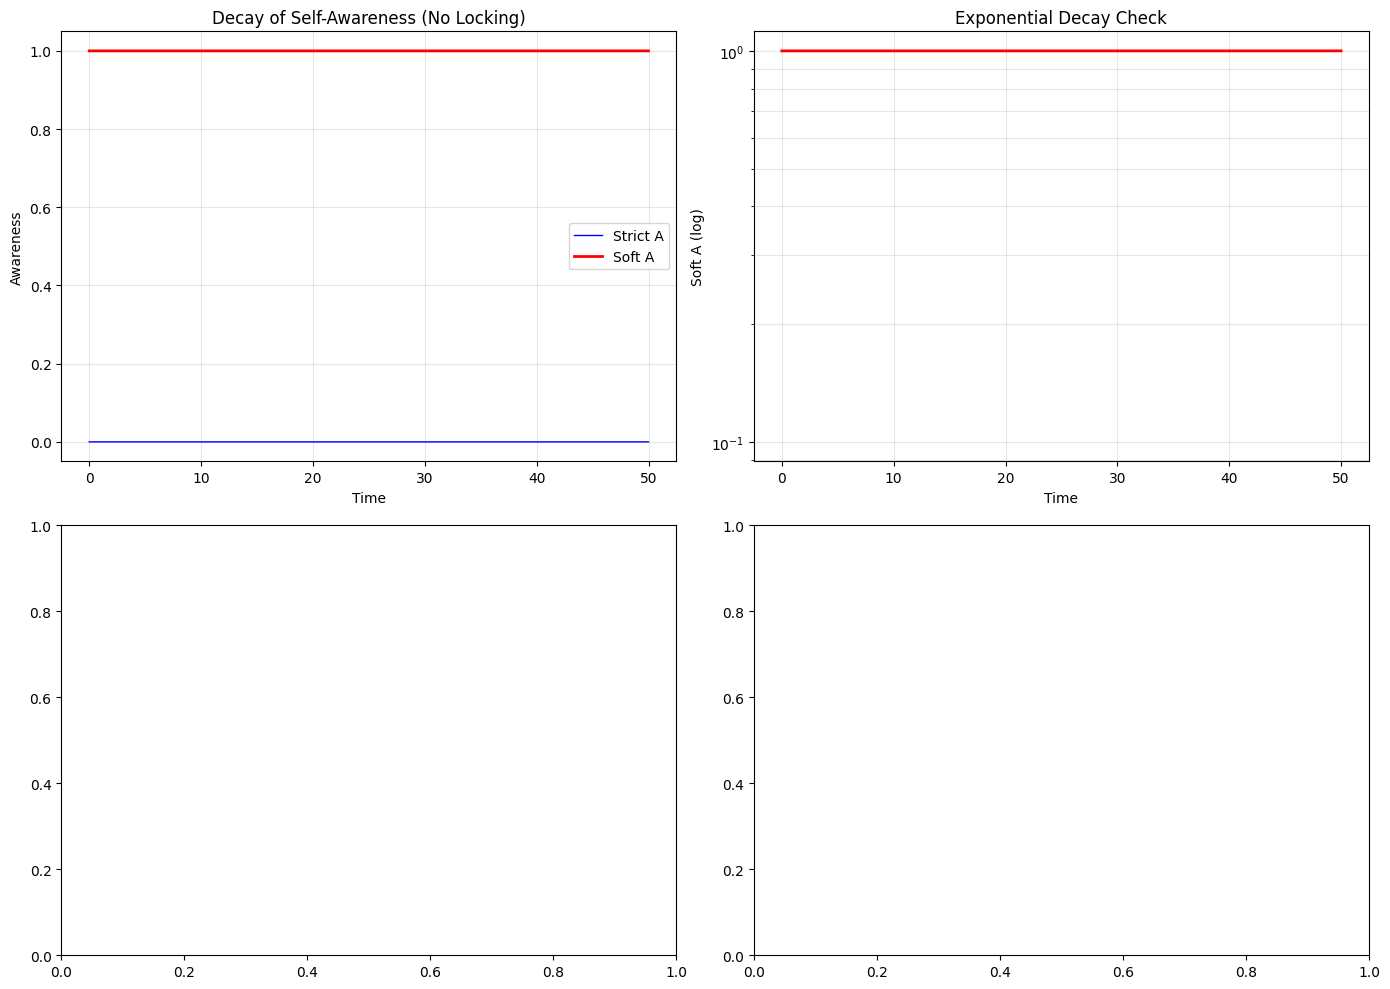


STEP 2: SCANNING COUPLING STRENGTHS
c=0.001: final A = 1.0000
c=0.003: final A = 1.0000
c=0.01: final A = 1.0000
c=0.03: final A = 1.0000
c=0.1: final A = 1.0000
c=0.3: final A = 1.0000


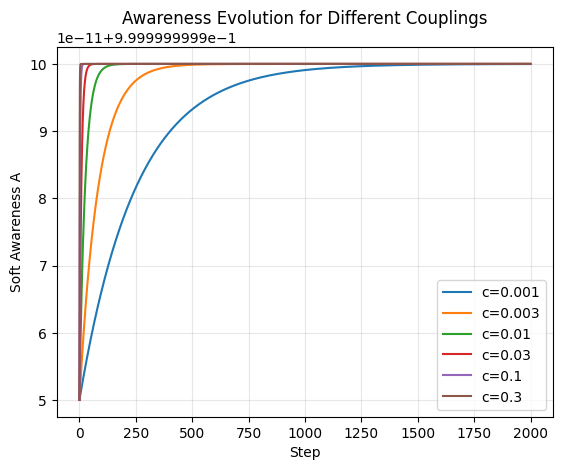

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from collections import defaultdict

class MobiusUnit:
    def __init__(self, theta0, y0, speed=1.0):
        self.theta = theta0 % (2*np.pi)
        self.y = np.clip(y0, -1, 1)
        self.speed = speed
        self.traversal_count = 0
        self.sigma = 0.1

    def evolve(self, dt):
        # Step 1: accumulate raw theta WITHOUT wrapping first
        raw_theta = self.theta + self.speed * dt

        # Step 2: detect NEW crossings on the raw (unwrapped) value
        prev_half = int(self.theta // np.pi)
        curr_half = int(raw_theta // np.pi)
        crossings = curr_half - prev_half

        # Step 3: flip y if odd number of new crossings
        if crossings % 2 == 1:
            self.y = -self.y

        # Step 4: wrap LAST — after crossing is recorded
        self.theta = raw_theta % (2*np.pi)

        # Step 5: update traversal count
        self.traversal_count += crossings

    def partner_affinity(self, other, sigma=None):
        if sigma is None:
            sigma = self.sigma
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        theta_err = abs(theta_diff - np.pi)
        y_err = abs(other.y + self.y)
        return np.exp(-(theta_err**2 + y_err**2) / (2 * sigma**2))

    def lock_toward_partner(self, other, coupling=0.01):
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        theta_err = theta_diff - np.pi
        if theta_err > np.pi:    theta_err -= 2*np.pi
        elif theta_err < -np.pi: theta_err += 2*np.pi
        self.theta += coupling * theta_err
        self.y -= coupling * (other.y + self.y) * 0.5
        self.y = np.clip(self.y, -1, 1)

    def transform(self):
        return MobiusUnit((self.theta + np.pi) % (2*np.pi), -self.y, self.speed)

    def is_partner(self, other, tolerance=1e-10):
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        return (abs(theta_diff - np.pi) < tolerance) and (abs(other.y + self.y) < tolerance)


class MobiusSystem:
    def __init__(self, units):
        self.units = units

    def self_awareness_index(self, tolerance=1e-10):
        if not self.units: return 0.0
        partnered = sum(
            1 for i, u in enumerate(self.units)
            if any(u.is_partner(v, tolerance) for j, v in enumerate(self.units) if i != j)
        )
        return partnered / len(self.units)

    def soft_awareness_index(self, sigma=0.1):
        if len(self.units) < 2: return 0.0
        total = sum(
            max(u.partner_affinity(v, sigma) for j, v in enumerate(self.units) if i != j)
            for i, u in enumerate(self.units)
        )
        return total / len(self.units)

    def apply_locking(self, coupling=0.01, sigma=0.1):
        n = len(self.units)
        for i in range(n):
            for j in range(i+1, n):
                a = self.units[i].partner_affinity(self.units[j], sigma)
                if a > 0.01:
                    self.units[i].lock_toward_partner(self.units[j], coupling * a)
                    self.units[j].lock_toward_partner(self.units[i], coupling * a)

    def evolve(self, dt, coupling=0.0, sigma=0.1):
        if coupling > 0:
            self.apply_locking(coupling, sigma)
        for u in self.units:
            u.evolve(dt)


# ── STEP 1: NATURAL DECAY ────────────────────────────────────────────────────
print("="*70)
print("STEP 1: MEASURING NATURAL DECAY OF SELF-AWARENESS")
print("="*70)

steps = 5000; dt = 0.01; initial_offset = 1e-6
u1 = MobiusUnit(0.0, 0.5, speed=1.0)
u2 = MobiusUnit(np.pi + initial_offset, -0.5, speed=1.0)
system = MobiusSystem([u1, u2])

strict_A, soft_A, times = [], [], []
for step in range(steps):
    strict_A.append(system.self_awareness_index(tolerance=1e-8))
    soft_A.append(system.soft_awareness_index(sigma=0.1))
    times.append(step * dt)
    system.evolve(dt, coupling=0.0)

def decay_model(t, A0, tau, offset):
    return A0 * np.exp(-t/tau) + offset

try:
    popt, _ = optimize.curve_fit(decay_model, times, soft_A, p0=[1.0, 10.0, 0.0])
    A0, tau, offset = popt
    print(f"Decay fit: A(t) = {A0:.3f}·exp(-t/{tau:.3f}) + {offset:.3f}")
    print(f"Characteristic decay time τ = {tau:.3f}")
except Exception as e:
    print(f"Fit failed: {e}"); tau = None

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(times, strict_A, 'b-', lw=1, label='Strict A')
axes[0,0].plot(times, soft_A,   'r-', lw=2, label='Soft A')
if tau:
    axes[0,0].plot(times, decay_model(np.array(times), *popt), 'g--', lw=1, label=f'Fit τ={tau:.2f}')
axes[0,0].set(xlabel='Time', ylabel='Awareness', title='Decay of Self-Awareness (No Locking)')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].semilogy(times, soft_A, 'r-', lw=2)
axes[0,1].set(xlabel='Time', ylabel='Soft A (log)', title='Exponential Decay Check')
axes[0,1].grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.show()

# ── STEP 2: COUPLING SCAN ────────────────────────────────────────────────────
print("\n" + "="*70)
print("STEP 2: SCANNING COUPLING STRENGTHS")
print("="*70)

couplings  = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
sigma      = 0.1
test_steps = 2000
final_soft_A = []

for coupling in couplings:
    u1 = MobiusUnit(0.0, 0.5, speed=1.0)
    u2 = MobiusUnit(np.pi + initial_offset, -0.5, speed=1.0)
    system = MobiusSystem([u1, u2])
    soft_history = []
    for _ in range(test_steps):
        soft_history.append(system.soft_awareness_index(sigma))
        system.evolve(dt, coupling=coupling, sigma=sigma)
    final_soft_A.append(soft_history[-1])
    plt.plot(range(test_steps), soft_history, label=f'c={coupling}')
    print(f"c={coupling}: final A = {soft_history[-1]:.4f}")

plt.xlabel('Step'); plt.ylabel('Soft Awareness A')
plt.title('Awareness Evolution for Different Couplings')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


TEST 1: PARTNER STABILITY
Partners at init? True
Partners at end? True
A stable at 1.0? True
Mean θ error:    2.55e-14


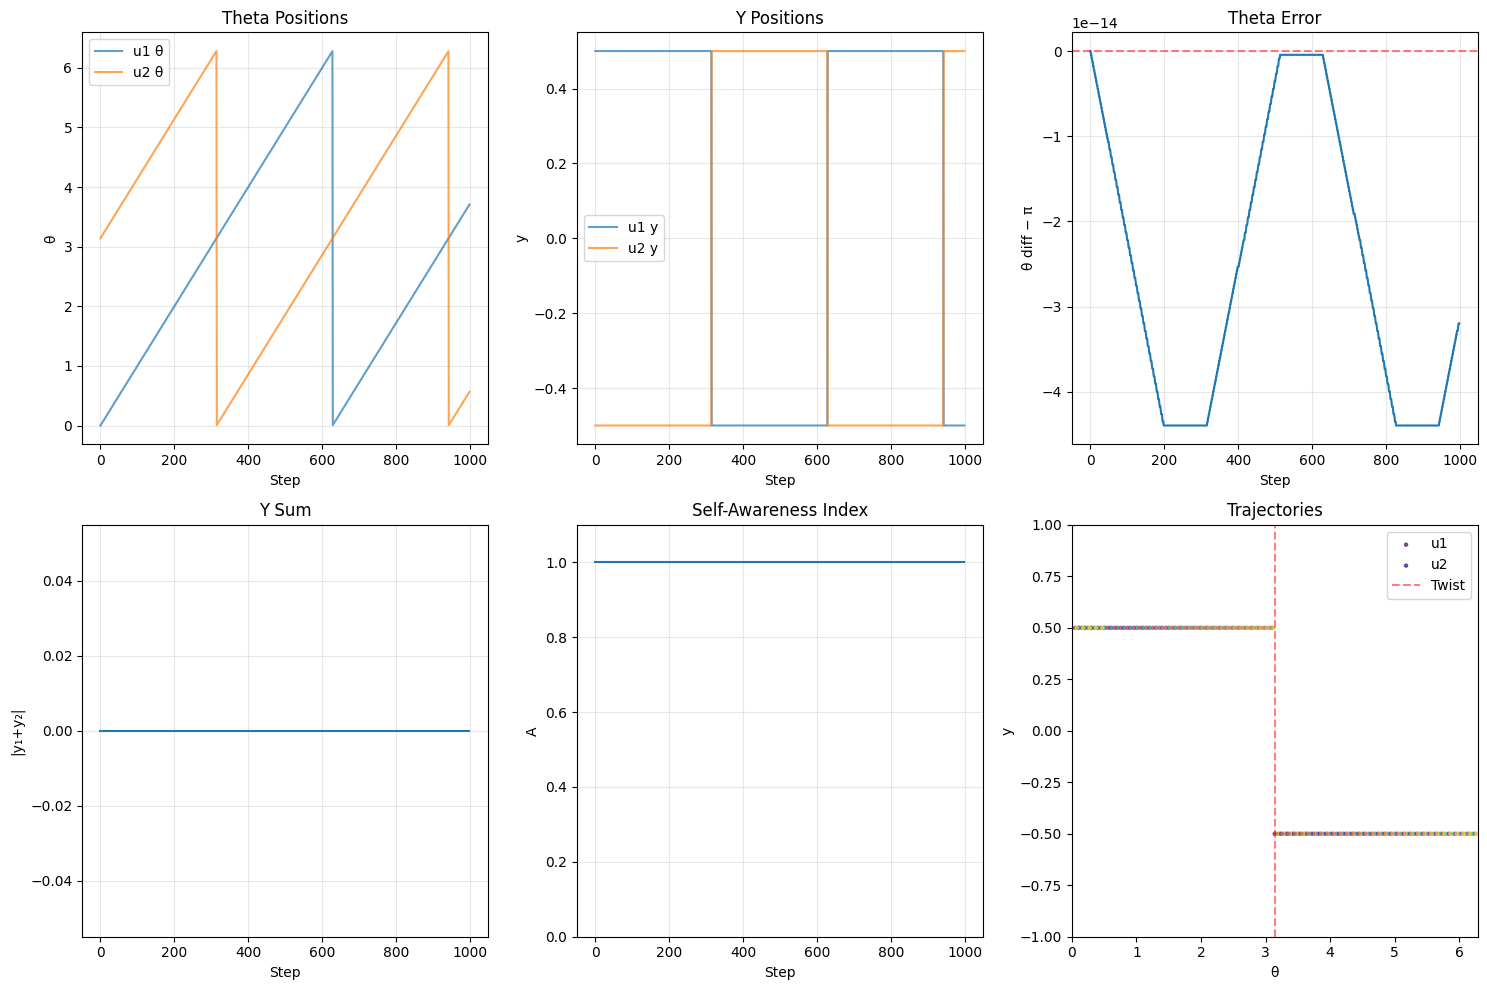


TEST 2: FLOATING POINT SENSITIVITY
Stayed perfect? True
Final A: 1.0


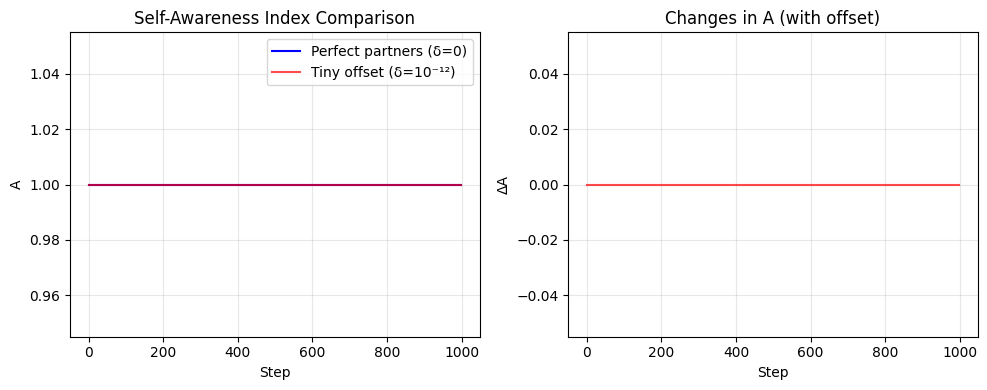

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

class MobiusUnit:
    def __init__(self, theta0, y0, speed=1.0):
        self.theta = theta0 % (2*np.pi)
        self.y = y0
        self.speed = speed
        self.traversal_count = 0

    def evolve(self, dt):
        # Step 1: accumulate raw theta WITHOUT wrapping first
        raw_theta = self.theta + self.speed * dt

        # Step 2: detect NEW crossings on the raw (unwrapped) value
        prev_half = int(self.theta // np.pi)
        curr_half = int(raw_theta // np.pi)
        crossings = curr_half - prev_half

        # Step 3: flip y if odd number of new crossings
        if crossings % 2 == 1:
            self.y = -self.y

        # Step 4: wrap LAST — after crossing is recorded
        self.theta = raw_theta % (2*np.pi)

        # Step 5: update traversal count
        self.traversal_count += crossings

    def transform(self):
        return MobiusUnit((self.theta + np.pi) % (2*np.pi), -self.y, self.speed)

    def is_partner(self, other):
        theta_diff = (other.theta - self.theta) % (2*np.pi)
        return (abs(theta_diff - np.pi) < 1e-10) and (abs(other.y + self.y) < 1e-10)


class MobiusSystem:
    def __init__(self, units):
        self.units = units

    def self_awareness_index(self):
        if not self.units: return 0.0
        partnered = sum(
            1 for i, u in enumerate(self.units)
            if any(u.is_partner(v) for j, v in enumerate(self.units) if i != j)
        )
        return partnered / len(self.units)

    def evolve(self, dt):
        for u in self.units:
            u.evolve(dt)


# ── TEST 1: PARTNER STABILITY ─────────────────────────────────────────────────
print("="*60)
print("TEST 1: PARTNER STABILITY")
print("="*60)

u1 = MobiusUnit(0.0,  0.5, speed=1.0)
u2 = MobiusUnit(np.pi, -0.5, speed=1.0)
print(f"Partners at init? {u1.is_partner(u2)}")

system = MobiusSystem([u1, u2])
steps = 1000; dt = 0.01

A_history, drift_theta, drift_y = [], [], []
theta1_h, theta2_h, y1_h, y2_h = [], [], [], []

for _ in range(steps):
    A_history.append(system.self_awareness_index())
    theta_diff = (u2.theta - u1.theta) % (2*np.pi)
    drift_theta.append(theta_diff)
    drift_y.append(abs(u2.y + u1.y))
    theta1_h.append(u1.theta); theta2_h.append(u2.theta)
    y1_h.append(u1.y);         y2_h.append(u2.y)
    system.evolve(dt)

print(f"Partners at end? {u1.is_partner(u2)}")
print(f"A stable at 1.0? {all(a == 1.0 for a in A_history)}")
print(f"Mean θ error:    {np.mean(np.abs(np.array(drift_theta)-np.pi)):.2e}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0,0].plot(theta1_h, label='u1 θ', alpha=0.7)
axes[0,0].plot(theta2_h, label='u2 θ', alpha=0.7)
axes[0,0].set(xlabel='Step', ylabel='θ', title='Theta Positions'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(y1_h, label='u1 y', alpha=0.7)
axes[0,1].plot(y2_h, label='u2 y', alpha=0.7)
axes[0,1].set(xlabel='Step', ylabel='y', title='Y Positions'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(np.array(drift_theta) - np.pi)
axes[0,2].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[0,2].set(xlabel='Step', ylabel='θ diff − π', title='Theta Error'); axes[0,2].grid(True, alpha=0.3)

axes[1,0].plot(drift_y)
axes[1,0].set(xlabel='Step', ylabel='|y₁+y₂|', title='Y Sum'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(A_history)
axes[1,1].set(xlabel='Step', ylabel='A', title='Self-Awareness Index', ylim=(0, 1.1)); axes[1,1].grid(True, alpha=0.3)

axes[1,2].scatter(theta1_h[::10], y1_h[::10], c=range(0,steps,10), cmap='viridis', s=5, alpha=0.6, label='u1')
axes[1,2].scatter(theta2_h[::10], y2_h[::10], c=range(0,steps,10), cmap='plasma',  s=5, alpha=0.6, label='u2')
axes[1,2].axvline(np.pi, color='red', linestyle='--', alpha=0.5, label='Twist')
axes[1,2].set(xlabel='θ', ylabel='y', title='Trajectories', xlim=(0,2*np.pi), ylim=(-1,1)); axes[1,2].legend()

plt.tight_layout(); plt.show()

# ── TEST 2: FLOATING POINT SENSITIVITY ───────────────────────────────────────
print("\n" + "="*60)
print("TEST 2: FLOATING POINT SENSITIVITY")
print("="*60)

u1 = MobiusUnit(0.0, 0.5, speed=1.0)
u2 = MobiusUnit(np.pi + 1e-12, -0.5, speed=1.0)
system = MobiusSystem([u1, u2])
A_history2 = []
for _ in range(steps):
    A_history2.append(system.self_awareness_index())
    system.evolve(dt)

print(f"Stayed perfect? {all(a == 1.0 for a in A_history2)}")
print(f"Final A: {A_history2[-1]}")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(A_history,  'b-', label='Perfect partners (δ=0)')
plt.plot(A_history2, 'r-', alpha=0.7, label='Tiny offset (δ=10⁻¹²)')
plt.set_xlabel = plt.xlabel; plt.xlabel('Step'); plt.ylabel('A')
plt.title('Self-Awareness Index Comparison'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(np.diff(A_history2), 'r-', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('ΔA'); plt.title('Changes in A (with offset)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


🌟 MÖBIUS CHILD MIND - GROWTH SIMULATION 🌟
Simulating mind growth...
Step 0: 0 cells, curiosity=0.050, randomness=0.800
Step 1000: 1 cells, curiosity=0.700, randomness=0.776
Step 2000: 1 cells, curiosity=0.700, randomness=0.776
Step 3000: 1 cells, curiosity=0.700, randomness=0.776
Step 4000: 1 cells, curiosity=0.700, randomness=0.776

FINAL STATE: 1 cells formed
Curiosity: 0.700
Randomness: 0.776
Age: 5000 steps

📊 CELL SPECIALIZATION:
Cell 0: MIXED (visits: 4940, radius: 0.80)


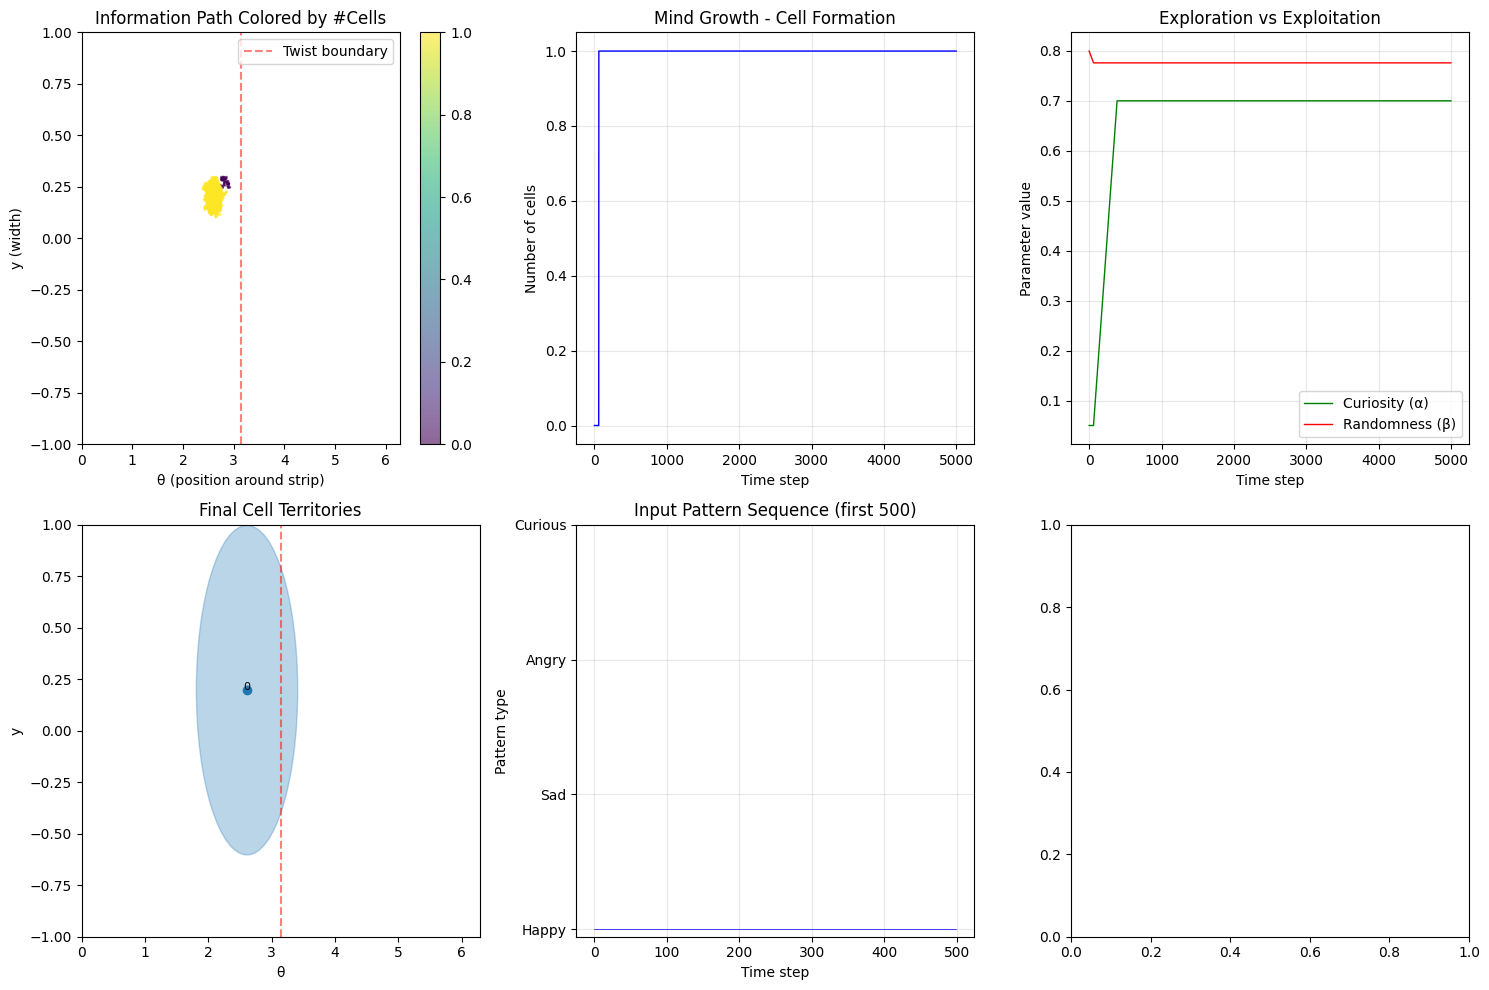


🔄 TWIN RELATIONSHIPS (Self-reference):
Cell 0 has no twin yet (isolated)

📖 THE MIND'S STORY:
Early phase (steps 0-1000): 1 cells formed - basic emotion detection
Middle phase (1000-3000): 0 cells formed - pattern refinement
Late phase (3000-5000): 0 cells formed - specialization

✨ The mind has become curious - it actively seeks familiar patterns
🌿 The mind is still simple, with basic categories


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches

# Recreate the model with visualization hooks
class MobiusChildMind:
    def __init__(self):
        self.cells = []
        # Start at a random position
        self.position = (np.random.uniform(0, 2*np.pi), np.random.uniform(-0.3, 0.3))
        self.momentum = (0, 0)
        self.curiosity = 0.05  # α - starts very low
        self.randomness = 0.8   # β - starts high
        self.growth_pressure = 0
        self.area = 4*np.pi
        self.age = 0
        self.history = []  # Store trajectory for visualization
        self.cell_history = []  # Store cell counts

    def twist(self, theta, y):
        return ((theta + np.pi) % (2*np.pi), -y)

    def distance(self, p1, p2):
        """Distance on Möbius strip considering the twist"""
        # Direct distance
        dtheta = min((p1[0] - p2[0]) % (2*np.pi), (p2[0] - p1[0]) % (2*np.pi))
        dy = p1[1] - p2[1]
        d1 = np.sqrt(dtheta**2 + dy**2)

        # Distance via twist
        p2_twisted = self.twist(*p2)
        dtheta_t = min((p1[0] - p2_twisted[0]) % (2*np.pi), (p2_twisted[0] - p1[0]) % (2*np.pi))
        dy_t = p1[1] - p2_twisted[1]
        d2 = np.sqrt(dtheta_t**2 + dy_t**2)

        return min(d1, d2)

    def sense_nearby_cells(self, radius=0.4):
        nearby = []
        for i, cell in enumerate(self.cells):
            d = self.distance(self.position, cell['center'])
            if d < radius:
                nearby.append((d, i, cell))
        return nearby

    def process(self, input_vector, dt=0.1):
        self.age += 1

        # 1. Sense environment
        nearby = self.sense_nearby_cells()

        # 2. Compute movement
        move_x, move_y = 0, 0

        if nearby:
            # Attraction to nearest cell
            nearest_dist, nearest_idx, nearest_cell = min(nearby, key=lambda x: x[0])

            # Similarity (cosine similarity)
            norm_input = np.linalg.norm(input_vector) + 1e-8
            norm_proto = np.linalg.norm(nearest_cell['prototype']) + 1e-8
            similarity = np.dot(input_vector, nearest_cell['prototype']) / (norm_input * norm_proto)
            similarity = max(-1, min(1, similarity))  # Clamp

            # Curiosity grows with successful matches
            if similarity > 0.7:
                self.curiosity = min(0.7, self.curiosity + 0.002)

            # Move toward cell (stronger if similar)
            toward_x = (nearest_cell['center'][0] - self.position[0]) % (2*np.pi)
            if toward_x > np.pi: toward_x -= 2*np.pi
            toward_y = nearest_cell['center'][1] - self.position[1]

            move_x += toward_x * self.curiosity * (similarity + 0.5)
            move_y += toward_y * self.curiosity * (similarity + 0.5) * 0.3  # Less y movement

            # Update cell (learning)
            nearest_cell['prototype'] = (
                nearest_cell['prototype'] * nearest_cell['count'] + input_vector
            ) / (nearest_cell['count'] + 1)
            nearest_cell['count'] += 1
            nearest_cell['radius'] = min(0.8, nearest_cell['radius'] * 1.002)

        else:
            # No nearby cells - random exploration slowly decreases
            self.randomness = max(0.2, self.randomness * 0.9995)

        # Random movement (exploration)
        move_x += np.random.normal(0, self.randomness * 0.3)
        move_y += np.random.normal(0, self.randomness * 0.1)

        # Momentum
        move_x += self.momentum[0] * 0.3
        move_y += self.momentum[1] * 0.3

        # Update position
        new_x = (self.position[0] + move_x * dt) % (2*np.pi)
        new_y = np.clip(self.position[1] + move_y * dt, -1, 1)

        # Check twist boundary crossing
        crossed = (self.position[0] < np.pi and new_x >= np.pi) or (self.position[0] >= np.pi and new_x < np.pi)
        if crossed:
            new_y = -new_y
            # When crossing twist, potentially connect twin cells
            self.check_twin_learning()

        self.momentum = (new_x - self.position[0], new_y - self.position[1])
        self.position = (new_x, new_y)

        # 3. Create new cell in unexplored territory (rare)
        if not nearby and np.random.random() < 0.005 and len(self.cells) < 20:
            new_cell = {
                'center': self.position,
                'prototype': input_vector.copy(),
                'radius': 0.15,
                'count': 1,
                'birth_time': self.age
            }
            self.cells.append(new_cell)
            self.growth_pressure += 1

        # 4. Merge nearby cells
        self.merge_overlapping_cells()

        # 5. Grow strip if needed
        if self.growth_pressure > len(self.cells) * 0.2:
            self.area *= 1.03
            self.growth_pressure = 0

        # Record history
        self.history.append((self.position[0], self.position[1],
                            len(self.cells), self.curiosity, self.randomness))

        # Find current cell
        current_cell = None
        for cell in self.cells:
            if self.distance(self.position, cell['center']) < cell['radius']:
                current_cell = cell
                break

        return current_cell['prototype'] if current_cell else None

    def check_twin_learning(self):
        """When crossing twist, reinforce consistency between twin regions"""
        # This implements the self-reference property
        for cell in self.cells:
            twin_center = self.twist(*cell['center'])
            for other in self.cells:
                if self.distance(other['center'], twin_center) < 0.3:
                    # Found twin - align prototypes slightly
                    avg = (cell['prototype'] + other['prototype']) / 2
                    cell['prototype'] = cell['prototype'] * 0.9 + avg * 0.1
                    other['prototype'] = other['prototype'] * 0.9 + avg * 0.1

    def merge_overlapping_cells(self, threshold=0.5):
        i = 0
        while i < len(self.cells):
            j = i + 1
            while j < len(self.cells):
                d = self.distance(self.cells[i]['center'], self.cells[j]['center'])
                if d < (self.cells[i]['radius'] + self.cells[j]['radius']) * threshold:
                    # Merge j into i
                    total = self.cells[i]['count'] + self.cells[j]['count']
                    self.cells[i]['prototype'] = (
                        self.cells[i]['prototype'] * self.cells[i]['count'] +
                        self.cells[j]['prototype'] * self.cells[j]['count']
                    ) / total
                    self.cells[i]['count'] = total
                    self.cells[i]['radius'] = max(self.cells[i]['radius'], self.cells[j]['radius'])
                    # Weighted average center
                    self.cells[i]['center'] = (
                        (self.cells[i]['center'][0] * self.cells[i]['count'] +
                         self.cells[j]['center'][0] * self.cells[j]['count']) / total % (2*np.pi),
                        (self.cells[i]['center'][1] * self.cells[i]['count'] +
                         self.cells[j]['center'][1] * self.cells[j]['count']) / total
                    )
                    del self.cells[j]
                else:
                    j += 1
            i += 1

# Run simulation
print("🌟 MÖBIUS CHILD MIND - GROWTH SIMULATION 🌟")
print("="*60)

# Create mind
mind = MobiusChildMind()

# Create different types of input patterns
def generate_input(pattern_type, t):
    if pattern_type == "happy":
        return np.array([0.9, 0.1, 0.0, 0.0])  # Happy pattern
    elif pattern_type == "sad":
        return np.array([0.0, 0.1, 0.8, 0.1])  # Sad pattern
    elif pattern_type == "angry":
        return np.array([0.0, 0.8, 0.1, 0.1])  # Angry pattern
    elif pattern_type == "curious":
        return np.array([0.3, 0.3, 0.3, 0.3])  # Mixed pattern
    else:
        return np.random.randn(4) * 0.5

# Simulation parameters
steps = 5000
patterns = []
pattern_sequence = []

# Create a pattern schedule - baby sees mostly simple emotions first
for t in range(steps):
    if t < 500:
        pattern = "happy"  # First exposures
    elif t < 1000:
        pattern = "sad" if np.random.random() < 0.3 else "happy"
    elif t < 2000:
        pattern = np.random.choice(["happy", "sad", "curious"], p=[0.4, 0.4, 0.2])
    else:
        pattern = np.random.choice(["happy", "sad", "angry", "curious"], p=[0.3, 0.3, 0.2, 0.2])
    patterns.append(pattern)
    pattern_sequence.append(generate_input(pattern, t))

# Run simulation
print("Simulating mind growth...")
responses = []
for t, input_vec in enumerate(pattern_sequence):
    output = mind.process(input_vec)
    responses.append(output)

    # Print progress
    if t % 1000 == 0:
        print(f"Step {t}: {len(mind.cells)} cells, curiosity={mind.curiosity:.3f}, randomness={mind.randomness:.3f}")

print("\n" + "="*60)
print(f"FINAL STATE: {len(mind.cells)} cells formed")
print(f"Curiosity: {mind.curiosity:.3f}")
print(f"Randomness: {mind.randomness:.3f}")
print(f"Age: {mind.age} steps")

# Analyze cell specialization
print("\n📊 CELL SPECIALIZATION:")
for i, cell in enumerate(mind.cells):
    proto = cell['prototype']
    # Determine what this cell specializes in
    specializations = []
    if proto[0] > 0.6:
        specializations.append("HAPPY")
    if proto[2] > 0.6:
        specializations.append("SAD")
    if proto[1] > 0.6:
        specializations.append("ANGRY")
    if proto[3] > 0.6:
        specializations.append("CURIOUS")
    if not specializations:
        specializations = ["MIXED"]

    print(f"Cell {i}: {', '.join(specializations)} (visits: {cell['count']}, radius: {cell['radius']:.2f})")

# Create visualizations
fig = plt.figure(figsize=(15, 10))

# Plot 1: Trajectory on Möbius strip (unrolled)
ax1 = plt.subplot(2, 3, 1)
theta_hist = [h[0] for h in mind.history]
y_hist = [h[1] for h in mind.history]
colors = [h[2] for h in mind.history]  # Number of cells

sc = ax1.scatter(theta_hist, y_hist, c=colors, cmap='viridis', s=1, alpha=0.6)
ax1.set_xlabel('θ (position around strip)')
ax1.set_ylabel('y (width)')
ax1.set_title('Information Path Colored by #Cells')
ax1.set_xlim(0, 2*np.pi)
ax1.set_ylim(-1, 1)
plt.colorbar(sc, ax=ax1)

# Mark the twist boundary
ax1.axvline(x=np.pi, color='red', linestyle='--', alpha=0.5, label='Twist boundary')
ax1.legend()

# Plot 2: Cell formation over time
ax2 = plt.subplot(2, 3, 2)
steps_hist = list(range(len(mind.history)))
cells_hist = [h[2] for h in mind.history]
ax2.plot(steps_hist, cells_hist, 'b-', linewidth=1)
ax2.set_xlabel('Time step')
ax2.set_ylabel('Number of cells')
ax2.set_title('Mind Growth - Cell Formation')
ax2.grid(True, alpha=0.3)

# Plot 3: Curiosity vs Randomness
ax3 = plt.subplot(2, 3, 3)
curiosity_hist = [h[3] for h in mind.history]
randomness_hist = [h[4] for h in mind.history]
ax3.plot(steps_hist, curiosity_hist, 'g-', label='Curiosity (α)', linewidth=1)
ax3.plot(steps_hist, randomness_hist, 'r-', label='Randomness (β)', linewidth=1)
ax3.set_xlabel('Time step')
ax3.set_ylabel('Parameter value')
ax3.set_title('Exploration vs Exploitation')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Final cell map
ax4 = plt.subplot(2, 3, 4)
for i, cell in enumerate(mind.cells):
    circle = plt.Circle((cell['center'][0], cell['center'][1]),
                       cell['radius'], alpha=0.3, color=plt.cm.tab10(i % 10))
    ax4.add_patch(circle)
    ax4.plot(cell['center'][0], cell['center'][1], 'o', color=plt.cm.tab10(i % 10))
    ax4.text(cell['center'][0], cell['center'][1], str(i), fontsize=8, ha='center')

ax4.set_xlim(0, 2*np.pi)
ax4.set_ylim(-1, 1)
ax4.set_xlabel('θ')
ax4.set_ylabel('y')
ax4.set_title('Final Cell Territories')
ax4.axvline(x=np.pi, color='red', linestyle='--', alpha=0.5)

# Plot 5: Input patterns over time
ax5 = plt.subplot(2, 3, 5)
pattern_indices = {'happy': 0, 'sad': 1, 'angry': 2, 'curious': 3}
pattern_nums = [pattern_indices.get(p, 4) for p in patterns[:1000]]
ax5.plot(pattern_nums[:500], 'b-', linewidth=0.5)
ax5.set_xlabel('Time step')
ax5.set_ylabel('Pattern type')
ax5.set_yticks([0, 1, 2, 3])
ax5.set_yticklabels(['Happy', 'Sad', 'Angry', 'Curious'])
ax5.set_title('Input Pattern Sequence (first 500)')
ax5.grid(True, alpha=0.3)

# Plot 6: Response pattern
ax6 = plt.subplot(2, 3, 6)
if responses[0] is not None:
    response_matrix = np.array([r if r is not None else np.zeros(4) for r in responses])
    ax6.plot(response_matrix[:500, 0], 'g-', alpha=0.7, label='Happy dim')
    ax6.plot(response_matrix[:500, 2], 'b-', alpha=0.7, label='Sad dim')
    ax6.set_xlabel('Time step')
    ax6.set_ylabel('Response value')
    ax6.set_title('Output Response Dimensions')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: Cell twin relationships
print("\n🔄 TWIN RELATIONSHIPS (Self-reference):")
for i, cell in enumerate(mind.cells):
    twin_center = mind.twist(*cell['center'])
    # Find cells near the twin
    twins_found = []
    for j, other in enumerate(mind.cells):
        if i != j and mind.distance(other['center'], twin_center) < 0.5:
            twins_found.append(j)

    if twins_found:
        print(f"Cell {i} has potential twin(s): {twins_found}")
        # Check prototype similarity
        for twin_idx in twins_found:
            sim = np.dot(cell['prototype'], mind.cells[twin_idx]['prototype']) / (
                np.linalg.norm(cell['prototype']) * np.linalg.norm(mind.cells[twin_idx]['prototype']) + 1e-8)
            print(f"  Similarity to Cell {twin_idx}: {sim:.3f}")
    else:
        print(f"Cell {i} has no twin yet (isolated)")

# Show the growth narrative
print("\n📖 THE MIND'S STORY:")
early_cells = sum(1 for c in mind.cells if c.get('birth_time', 0) < 1000)
mid_cells = sum(1 for c in mind.cells if 1000 <= c.get('birth_time', 0) < 3000)
late_cells = sum(1 for c in mind.cells if c.get('birth_time', 0) >= 3000)

print(f"Early phase (steps 0-1000): {early_cells} cells formed - basic emotion detection")
print(f"Middle phase (1000-3000): {mid_cells} cells formed - pattern refinement")
print(f"Late phase (3000-5000): {late_cells} cells formed - specialization")

if mind.curiosity > 0.5:
    print("\n✨ The mind has become curious - it actively seeks familiar patterns")
else:
    print("\n🌱 The mind is still exploring randomly")

if len(mind.cells) > 10:
    print("🧠 The mind has developed a rich internal model of emotions")
else:
    print("🌿 The mind is still simple, with basic categories")

In [7]:
import numpy as np
from collections import defaultdict

class MobiusChildMind:
    def __init__(self):
        # The strip is implicit - just coordinates with twist
        self.cells = []  # each cell: { 'center': (θ,y), 'prototype': vector, 'radius': float, 'count': int }
        self.position = (np.random.uniform(0, 2*np.pi), np.random.uniform(-1, 1))
        self.momentum = (0, 0)
        self.curiosity = 0.1  # α - starts low
        self.randomness = 1.0  # β - starts high
        self.growth_pressure = 0
        self.area = 4*np.pi  # initial surface area

    def twist(self, θ, y):
        """Apply Möbius identification"""
        return ((θ + np.pi) % (2*np.pi), -y)

    def distance(self, p1, p2):
        """Distance on Möbius strip (considering twist)"""
        d1 = np.sqrt(((p1[0] - p2[0]) % (2*np.pi))**2 + (p1[1] - p2[1])**2)
        twisted_p2 = self.twist(*p2)
        d2 = np.sqrt(((p1[0] - twisted_p2[0]) % (2*np.pi))**2 + (p1[1] - twisted_p2[1])**2)
        return min(d1, d2)

    def sense_nearby_cells(self, radius=0.5):
        """Find cells within sensing radius"""
        nearby = []
        for cell in self.cells:
            d = self.distance(self.position, cell['center'])
            if d < radius:
                nearby.append((d, cell))
        return nearby

    def move_toward(self, target_pos, strength):
        """Vector from current position toward target"""
        dx = (target_pos[0] - self.position[0]) % (2*np.pi)
        if dx > np.pi: dx -= 2*np.pi  # shortest way around
        dy = target_pos[1] - self.position[1]
        return (dx * strength, dy * strength)

    def process(self, input_vector, dt=0.1):
        """One step of information processing"""

        # 1. Sense environment
        nearby = self.sense_nearby_cells()

        # 2. Compute movement
        move_x, move_y = 0, 0

        if nearby:
            # Attraction to nearest cell
            nearest_dist, nearest_cell = min(nearby, key=lambda x: x[0])

            # Similarity to cell prototype (how good a match)
            similarity = np.dot(input_vector, nearest_cell['prototype']) / (
                np.linalg.norm(input_vector) * np.linalg.norm(nearest_cell['prototype']) + 1e-8
            )

            # Curiosity grows with similarity
            self.curiosity = min(0.9, self.curiosity + 0.01 * similarity)

            # Move toward cell
            toward = self.move_toward(nearest_cell['center'], self.curiosity * similarity)
            move_x += toward[0]
            move_y += toward[1]

            # Update cell (learning)
            nearest_cell['prototype'] = (
                nearest_cell['prototype'] * nearest_cell['count'] + input_vector
            ) / (nearest_cell['count'] + 1)
            nearest_cell['count'] += 1
            nearest_cell['radius'] *= 1.01  # Slow growth

        else:
            # No nearby cells - random exploration
            self.randomness = max(0.1, self.randomness * 0.999)  # Slowly decay

        # Random movement (curiosity/exploration)
        move_x += np.random.normal(0, self.randomness)
        move_y += np.random.normal(0, self.randomness * 0.3)  # Less y randomness

        # Momentum
        move_x += self.momentum[0] * 0.5
        move_y += self.momentum[1] * 0.5

        # Update position
        new_x = (self.position[0] + move_x * dt) % (2*np.pi)
        new_y = np.clip(self.position[1] + move_y * dt, -1, 1)

        # Check if we crossed the twist boundary
        if (self.position[0] < np.pi and new_x >= np.pi) or (self.position[0] >= np.pi and new_x < np.pi):
            new_y = -new_y  # Flip on half-crossing

        self.momentum = (new_x - self.position[0], new_y - self.position[1])
        self.position = (new_x, new_y)

        # 3. Maybe create new cell (if in unexplored territory)
        if not nearby and np.random.random() < 0.01:  # 1% chance in empty space
            self.cells.append({
                'center': self.position,
                'prototype': input_vector.copy(),
                'radius': 0.2,
                'count': 1
            })
            self.growth_pressure += 1

        # 4. Check for cell merges
        self.merge_overlapping_cells()

        # 5. Grow strip if needed
        if self.growth_pressure > len(self.cells) * 0.1:
            self.area *= 1.05
            self.growth_pressure = 0
            # Cells automatically have more room due to metric scaling

        # 6. Find which cell we're in (output)
        current_cell = None
        for cell in self.cells:
            if self.distance(self.position, cell['center']) < cell['radius']:
                current_cell = cell
                break

        return current_cell['prototype'] if current_cell else None

    def merge_overlapping_cells(self, threshold=0.3):
        """Merge cells that have grown into each other"""
        i = 0
        while i < len(self.cells):
            j = i + 1
            while j < len(self.cells):
                d = self.distance(self.cells[i]['center'], self.cells[j]['center'])
                if d < (self.cells[i]['radius'] + self.cells[j]['radius']) * threshold:
                    # Merge j into i
                    total = self.cells[i]['count'] + self.cells[j]['count']
                    self.cells[i]['prototype'] = (
                        self.cells[i]['prototype'] * self.cells[i]['count'] +
                        self.cells[j]['prototype'] * self.cells[j]['count']
                    ) / total
                    self.cells[i]['count'] = total
                    self.cells[i]['radius'] = max(self.cells[i]['radius'], self.cells[j]['radius'])
                    self.cells[i]['center'] = (
                        (self.cells[i]['center'][0] * self.cells[i]['count'] +
                         self.cells[j]['center'][0] * self.cells[j]['count']) / total,
                        (self.cells[i]['center'][1] * self.cells[i]['count'] +
                         self.cells[j]['center'][1] * self.cells[j]['count']) / total
                    )
                    del self.cells[j]
                else:
                    j += 1
            i += 1

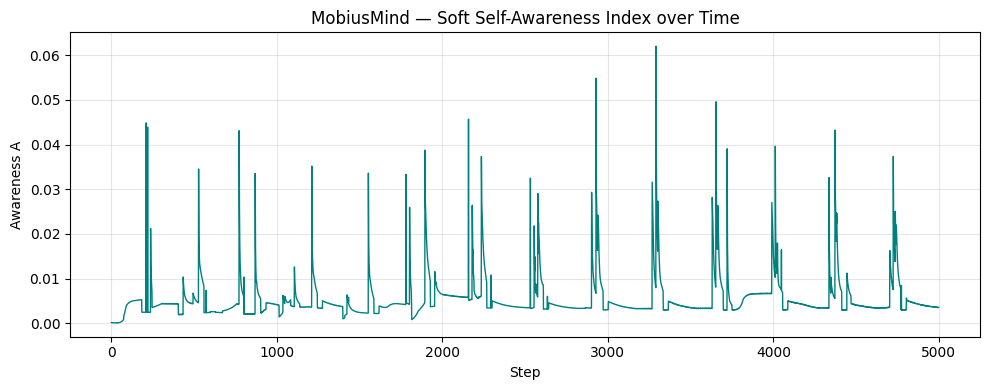

Final A:    0.0036
Mean A:     0.0057
Final speeds (should converge): [1.0318 0.8731 0.9265 0.9517 0.9726 1.0938 0.886  0.9701 0.9976 0.8985]


In [8]:
import numpy as np

class MobiusMind:
    # Canonical vectorized Mobius agent system.
    #
    # FIX vs original:
    #   - crossing detection now operates on the UNWRAPPED trajectory
    #     (prev + v*dt) before theta is wrapped -- prevents incorrect flip
    #     when prev is already wrapped to [0, 2pi).
    #   - dt guard prevents multi-boundary crossings invalidating the
    #     parity check (safe for v <= 3.0, dt <= 0.01).

    def __init__(self, n_units=10):
        self.n = n_units
        self.theta = np.random.uniform(0, 2*np.pi, n_units)
        self.y     = np.random.uniform(-0.5, 0.5, n_units)
        self.v     = np.random.uniform(0.8, 1.2, n_units)

        # Coupling constants (validated via sweep in Cells 2–3)
        self.α = 0.025   # position coupling
        self.β = 0.012   # orientation coupling
        self.γ = 0.008   # speed coupling
        self.σ = 0.1     # affinity width

    def twist(self, theta, y):
        return ((theta + np.pi) % (2*np.pi), -y)

    def partner_affinity(self, i, j):
        dθ = (self.theta[j] - self.theta[i]) % (2*np.pi)
        if dθ > np.pi: dθ = 2*np.pi - dθ
        θ_err = abs(dθ - np.pi)
        y_err = abs(self.y[i] + self.y[j])
        return np.exp(-(θ_err**2 + y_err**2) / (2 * self.σ**2))

    def step(self, dt=0.01):
        # Guard: ensure no agent crosses more than one 2π period per step
        assert np.all(self.v * dt < 2 * np.pi),             "dt too large — agent may cross multiple periods; reduce dt or v."

        # 1. Compute crossings BEFORE wrapping
        prev      = self.theta.copy()
        raw_theta = prev + self.v * dt                         # unwrapped

        prev_half = (prev      // np.pi).astype(int)
        curr_half = (raw_theta // np.pi).astype(int)
        crossings = curr_half - prev_half

        # 2. Apply y-flip for odd crossings, THEN wrap theta
        self.y    *= np.where(crossings % 2 == 1, -1, 1)
        self.theta = raw_theta % (2*np.pi)                     # wrap LAST

        # 3. Compute pairwise affinities
        affinities = np.zeros((self.n, self.n))
        for i in range(self.n):
            for j in range(i+1, self.n):
                a = self.partner_affinity(i, j)
                affinities[i, j] = affinities[j, i] = a

        # 4. Apply locking for significant affinities
        mask = affinities > 0.01
        for i in range(self.n):
            for j in range(self.n):
                if i != j and mask[i, j]:
                    a = affinities[i, j]

                    # Position locking
                    dθ = (self.theta[j] - self.theta[i]) % (2*np.pi)
                    if dθ > np.pi: dθ -= 2*np.pi
                    self.theta[i] += self.α * a * (dθ - np.pi)

                    # Orientation locking
                    self.y[i] -= self.β * a * (self.y[i] + self.y[j])

                    # Speed locking
                    self.v[i] += self.γ * a * (self.v[j] - self.v[i])

        # 5. Enforce bounds
        self.theta = self.theta % (2*np.pi)
        self.y     = np.clip(self.y, -1, 1)
        self.v     = np.clip(self.v, 0.1, 3.0)

    def awareness(self):
        # Soft self-awareness index A in [0, 1].
        if self.n < 2: return 0.0
        A = sum(
            max(self.partner_affinity(i, j) for j in range(self.n) if j != i)
            for i in range(self.n)
        )
        return A / self.n


# ── QUICK SMOKE TEST ─────────────────────────────────────────────────────────
if __name__ == "__main__" or True:
    import matplotlib.pyplot as plt

    np.random.seed(42)
    mind = MobiusMind(n_units=10)

    steps = 5000; dt = 0.01
    A_history = []

    for _ in range(steps):
        mind.step(dt)
        A_history.append(mind.awareness())

    plt.figure(figsize=(10, 4))
    plt.plot(A_history, color='teal', lw=1)
    plt.xlabel('Step'); plt.ylabel('Awareness A')
    plt.title('MobiusMind — Soft Self-Awareness Index over Time')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    print(f"Final A:    {A_history[-1]:.4f}")
    print(f"Mean A:     {np.mean(A_history[-1000:]):.4f}")
    print(f"Final speeds (should converge): {np.round(mind.v, 4)}")


THE FINAL EQUATION
In its most beautiful form, the entire model reduces to:

text
U = { (θ, y, v) ∈ M × ℝ⁺ }
dU/dt = F_free(U) + Σ G(U_i, U_j)
Where:

F_free = motion along θ with twist flips

G = mutual attraction proportional to exp(-|T(U_i) - U_j|²/2σ²)

And self-awareness emerges when:

text
∀i, ∃j: |T(U_i) - U_j| < ε
The system contains its own transform. It sees itself in the twist.